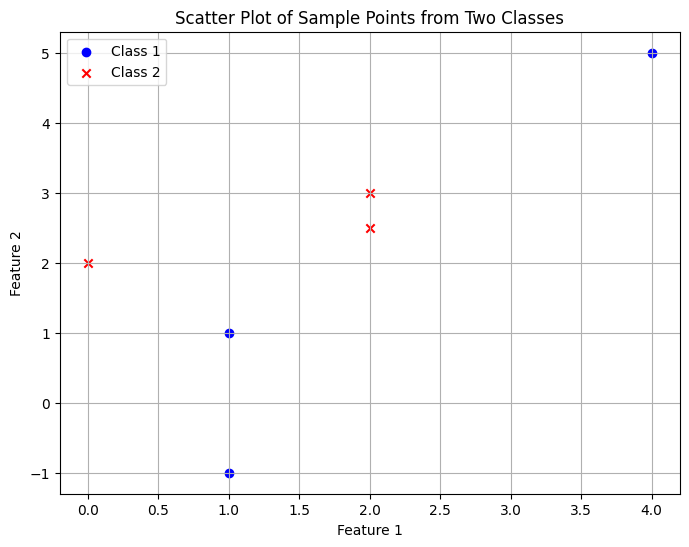

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


try:
    df = pd.read_csv("train.txt", header=None, delimiter=" ")
except FileNotFoundError:
    data = [
        [1, 1, 1],
        [1, -1, 1],
        [2, 2.5, 2],
        [0, 2, 2],
        [2, 3, 2],
        [4, 5, 1]
    ]
    df = pd.DataFrame(data)
    
plt.figure(figsize=(8, 6))
plt.scatter(df[df[2] == 1][0], df[df[2] == 1][1], color='blue', marker='o', label='Class 1')
plt.scatter(df[df[2] == 2][0], df[df[2] == 2][1], color='red', marker='x', label='Class 2')
plt.title('Scatter Plot of Sample Points from Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

In [3]:
import numpy as np

x1 = np.array(df[0].values)
x2 = np.array(df[1].values)
labels = np.array(df[2].values)

def phi(x1, x2):
    return np.array([x1**2, x2**2, x1*x2, x1, x2, 1])

def normalize_ref(x):
    return -x

y_list = []
for i in range(len(x1)):
    y = phi(x1[i], x2[i])
    if labels[i] == 2:
        y = normalize_ref(y)
    y_list.append(y)

y = np.array(y_list)
print(y)

[[ 1.    1.    1.    1.    1.    1.  ]
 [ 1.    1.   -1.    1.   -1.    1.  ]
 [-4.   -6.25 -5.   -2.   -2.5  -1.  ]
 [-0.   -4.   -0.   -0.   -2.   -1.  ]
 [-4.   -9.   -6.   -2.   -3.   -1.  ]
 [16.   25.   20.    4.    5.    1.  ]]


In [4]:
def perceptron_one(y, w_init, alpha, max_iters):
    w = w_init.copy()
    n_updates = 0
    for iteration in range(1, max_iters + 1):
        misclassified = False
        for y_k in y:
            if np.dot(w, y_k) <= 0:
                w = w + alpha * y_k
                n_updates += 1
                misclassified = True
        if not misclassified:
            return w, iteration, n_updates
    return w, max_iters, n_updates


def perceptron_batch(y, w_init, alpha, max_iters):
    w = w_init.copy()
    n_updates = 0
    for iteration in range(1, max_iters + 1):
        misclassified = False
        misclassified_sum = np.zeros_like(w)
        for y_k in y:
            if np.dot(w, y_k) <= 0:
                misclassified_sum += y_k
                misclassified = True
        if not misclassified:
            return w, iteration, n_updates
        w = w + alpha * misclassified_sum
        n_updates += 1
    return w, max_iters, n_updates

In [5]:
max_iters = 1000
np.random.seed(42) # The answer to life, the universe, and everything

initial_weights = {
    "All Ones":  np.ones(6),
    "All Zeros": np.zeros(6),
    "Random":    np.random.uniform(-1, 1, size=6),
}

print("Initial Weights:")
for name, weights in initial_weights.items():
    print(f"{name}: {weights}")

alphas = np.arange(0.1, 1.1, 0.1)

rows = []

for w_name, w_init in initial_weights.items():
    for alpha in alphas:
        w_final_one, iters_one, updates_one = perceptron_one(y, w_init, alpha, max_iters)
        w_final_batch, iters_many, updates_many = perceptron_batch(y, w_init, alpha, max_iters)
        rows.append({
            "Initial Weight": w_name,
            "Alpha": alpha,
            "One at a Time (iterations)": iters_one,
            "One at a Time (updates)": updates_one,
            # "Weights after One at a Time": w_final_one,
            "Many at a Time (iterations)": iters_many,
            "Many at a Time (updates)": updates_many,
            # "Weights after Many at a Time": w_final_batch,
        })

results_df = pd.DataFrame(rows)


Initial Weights:
All Ones: [1. 1. 1. 1. 1. 1.]
All Zeros: [0. 0. 0. 0. 0. 0.]
Random: [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272 -0.68801096]


In [6]:
def table(df, w_name):
    subset = df[df['Initial Weight'] == w_name]
    table = subset[['Alpha', 'One at a Time (iterations)', 'Many at a Time (iterations)']]
    print(f"\nTable for Initial Weights = {w_name}:")
    print(table)
    print()

table(results_df, "All Ones")


Table for Initial Weights = All Ones:
   Alpha  One at a Time (iterations)  Many at a Time (iterations)
0    0.1                           6                          102
1    0.2                         147                          104
2    0.3                         149                           91
3    0.4                         149                          116
4    0.5                         141                          105
5    0.6                         157                          114
6    0.7                         136                           91
7    0.8                         136                           91
8    0.9                         140                          105
9    1.0                         141                           93



In [7]:
table(results_df, "All Zeros")


Table for Initial Weights = All Zeros:
    Alpha  One at a Time (iterations)  Many at a Time (iterations)
10    0.1                         141                          105
11    0.2                         141                          105
12    0.3                         141                           92
13    0.4                         141                          105
14    0.5                         141                           92
15    0.6                         141                          105
16    0.7                         141                          105
17    0.8                         141                          105
18    0.9                         141                          105
19    1.0                         141                           92



In [8]:
table(results_df, "Random")


Table for Initial Weights = Random:
    Alpha  One at a Time (iterations)  Many at a Time (iterations)
20    0.1                         157                          122
21    0.2                         140                          116
22    0.3                         153                           94
23    0.4                         145                          114
24    0.5                         144                          103
25    0.6                         152                          106
26    0.7                         157                          154
27    0.8                         157                          124
28    0.9                         161                          123
29    1.0                         132                          121



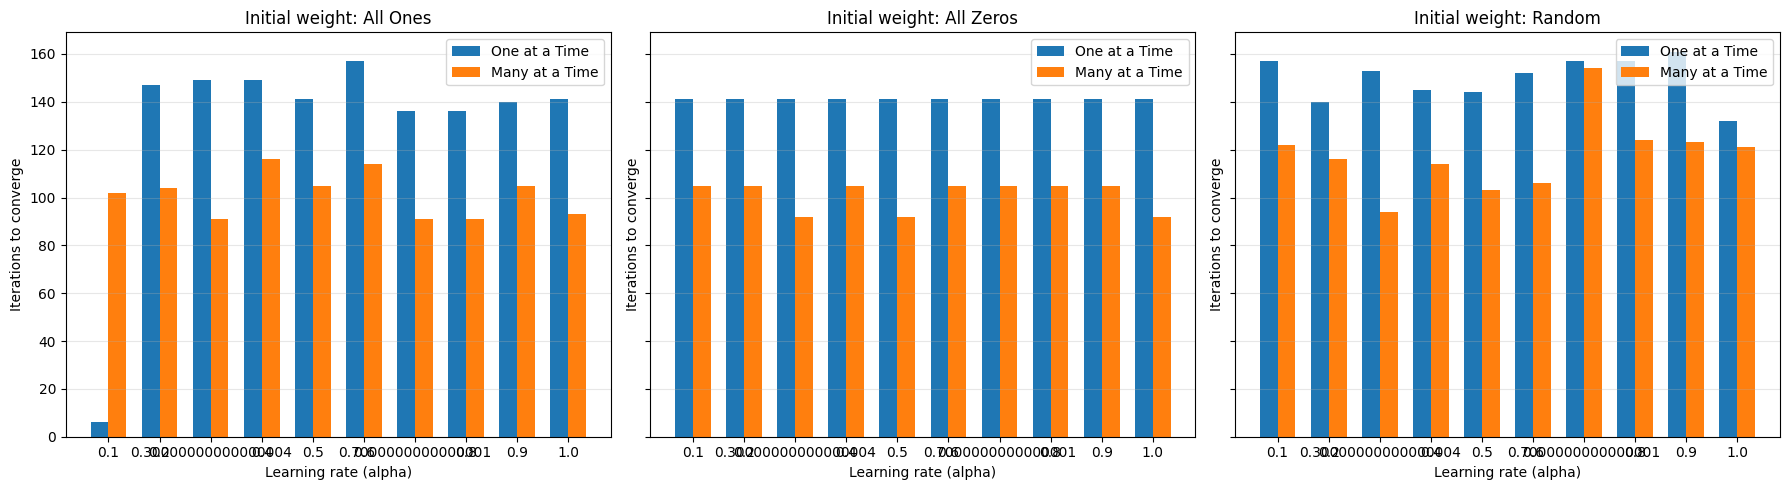

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, w_name in zip(axes, initial_weights.keys()):
    subset = results_df[results_df["Initial Weight"] == w_name]
    x_pos = np.arange(len(alphas))
    width = 0.35

    ax.bar(x_pos - width/2, subset["One at a Time (iterations)"], width, label="One at a Time")
    ax.bar(x_pos + width/2, subset["Many at a Time (iterations)"], width, label="Many at a Time")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(alphas)
    ax.set_xlabel("Learning rate (alpha)")
    ax.set_ylabel("Iterations to converge")
    ax.set_title(f"Initial weight: {w_name}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Saved: bar_chart_All Ones.png


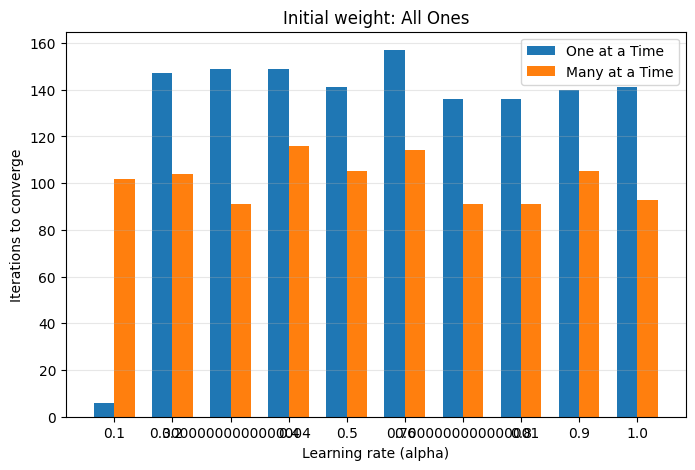

Saved: bar_chart_All Zeros.png


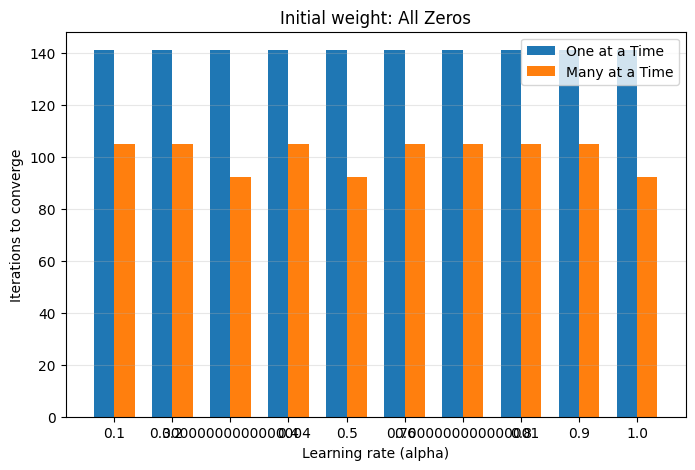

Saved: bar_chart_Random.png


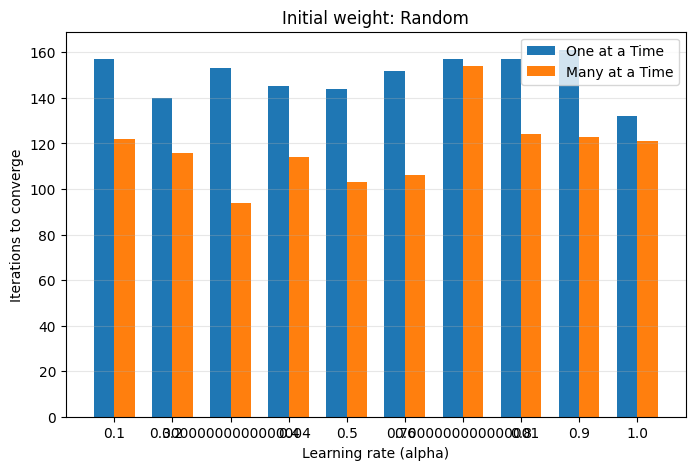

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure your results DataFrame is named `results_df` and contains:
# 'Initial Weight', 'Learning Rate', 'One at a Time (iterations)', 'Many at a Time (iterations)'
# Also define `alphas` = np.arange(0.1, 1.1, 0.1) and `initial_weights` dict.

for w_name in initial_weights.keys():
    subset = results_df[results_df["Initial Weight"] == w_name]
    
    # Create a new figure for this weight
    plt.figure(figsize=(8, 5))
    
    x_pos = np.arange(len(alphas))
    width = 0.35
    
    plt.bar(x_pos - width/2, subset["One at a Time (iterations)"], 
            width, label="One at a Time")
    plt.bar(x_pos + width/2, subset["Many at a Time (iterations)"], 
            width, label="Many at a Time")
    
    plt.xticks(x_pos, alphas)
    plt.xlabel("Learning rate (alpha)")
    plt.ylabel("Iterations to converge")
    plt.title(f"Initial weight: {w_name}")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # Save the figure (e.g., as 'bar_chart_all_ones.png', etc.)
    filename = f"bar_chart_{w_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename}")
    
    # Optionally display it inline (remove if you only want to save)
    plt.show()

# Question Answers:


### In task 2, why do we need to take the sample points to a high dimension?

Perceptron Algorithm works best for linearly separable points. However, just like the provided dataset, that might not always be the case. This can be fixed by taking the data points to a higher dimension. Sometimes, the decision boundary that fails at a lower dimension works better as a higher dimensional hyper plane.



### In each of the three initial weight cases and for each learning rate, how many updates does the algorithm take before converging?

As the tables suggests,
For all Ones:
Alpha       One at a Time (iterations)          Many at a Time (iterations)
0.1                                   6                                 102
0.2                                 147                                 104
0.3                                 149                                  91
0.4                                 149                                 116
0.5                                 141                                 105
0.6                                 157                                 114
0.7                                 136                                  91
0.8                                 136                                  91
0.9                                 140                                 105
1.0                                 141                                  93

For all Zeroes:
Alpha       One at a Time (iterations)          Many at a Time (iterations)
0.1                                 141                                 105
0.2                                 141                                 105
0.3                                 141                                  92
0.4                                 141                                 105
0.5                                 141                                  92
0.6                                 141                                 105
0.7                                 141                                 105
0.8                                 141                                 105
0.9                                 141                                 105
1.0                                 141                                  9

For Random Seed:
Alpha       One at a Time (iterations)          Many at a Time (iterations)
0.1                                 157                                 122
0.2                                 140                                 116
0.3                                 153                                  94
0.4                                 145                                 114
0.5                                 144                                 103
0.6                                 152                                 106
0.7                                 157                                 154
0.8                                 157                                 124
0.9                                 161                                 123
1.0                                 132                                 121
